In [1]:
# Quantum correction calculations to the linear E and in B magnetoconductivity. Positional shift formalism.
using Revise
using Optics_in_the_length_gauge
using LinearAlgebra
using Parameters
using Field_Induced_Hall_Effect
using Brillouin
using Bravais
using CairoMakie, BZpaths

  ** incremental compilation may be fatally broken for this module **



In [2]:
pathof(Optics_in_the_length_gauge)

"/Users/fernandopenaranda/.julia/packages/Optics_in_the_length_gauge/1TR0U/src/Optics_in_the_length_gauge.jl"

In [3]:
function rotate_z(θ, v)
    # θ = π / 3  # 60 degrees
    R = [
        cos(θ)  -sin(θ)  0;
        sin(θ)   cos(θ)  0;
        0        0       1
    ]
    return R * v
end

# KPATH
Γ = [0,0,0]
A = [0,0, π]
M =  2π/3 *  [1, 0, 0]
K1 = 2π/3 * [1, -1/sqrt(3), 0];
K2 = 2π/3 * [1, 1/sqrt(3), 0];

M = rotate_z(π/3, M)
K1 = rotate_z(2pi/3, K1)
K2 = rotate_z(pi/3, K2)


3-element Vector{Float64}:
 4.760838790634402e-17
 2.4183991523122903
 0.0

In [42]:
function bands(q, p, i)
    mat = ferroaxial_ham3d_spinfull(q,p.μ,p.Δ,p.t,p.tp, p.tpz, p.tc, p.tλ, p.tsx, p.tsy)
    ϵs, ψs = eigen(mat)   
    return ϵs[i]
end

function bands_ferroaxial_Gamma_M_K(p; a = 1)
    a1, a2, a3, δ1, δ2, δ3 = lattice_vectors(a)
    Rs = [a1,a2,a3] 
                 # point group (144 = p3_1)
    N = 200    #kpoints
    mysimpath = [Γ, M, K1, Γ .+ 1e-4, A .+ 1e-3, K2]
    ks = interpolate(mysimpath, N)
    ticks_vals = [bands(kpoint, p, 1) for kpoint in mysimpath]
    xvals = 1:length(ks)
    yvals = real.([bands(k, p, 1) for k in ks])
    position = [findmin(abs.(x .- yvals))[2] for x in ticks_vals]
    xticks = (vcat(position[1:5],[xvals[end]]), ["Γ", "M", "K", "Γ", "A", "K"]) 
    fig = Figure(); ax = Axis(fig[1,1], ylabel = "E [eV]", title = "μ = $(p.μ), Δ = $(p.Δ), t_perp = $(p.tpz), t = $(p.t), t2 = $(p.tc), t3 = $(p.tp), t_ca = $(p.tλ), t_sx = $(p.tsx), t_sy = $(p.tsy) [eV]",  xticks=xticks)
    colorlist = [:red, :orange, :blue, :green]
    for i in 1:4
        yvals = real.([bands(k, p, i) for k in ks])
        lines!(ax, xvals, yvals, color = colorlist[i])
    end
    println(position)
    # ylims!(ax, -10,9)
    # ax.yticks = (-10:9, string.(-10:9))
    xvals, fig
end


bands_ferroaxial_Gamma_M_K (generic function with 1 method)

[1, 33, 51, 88, 136, 197]


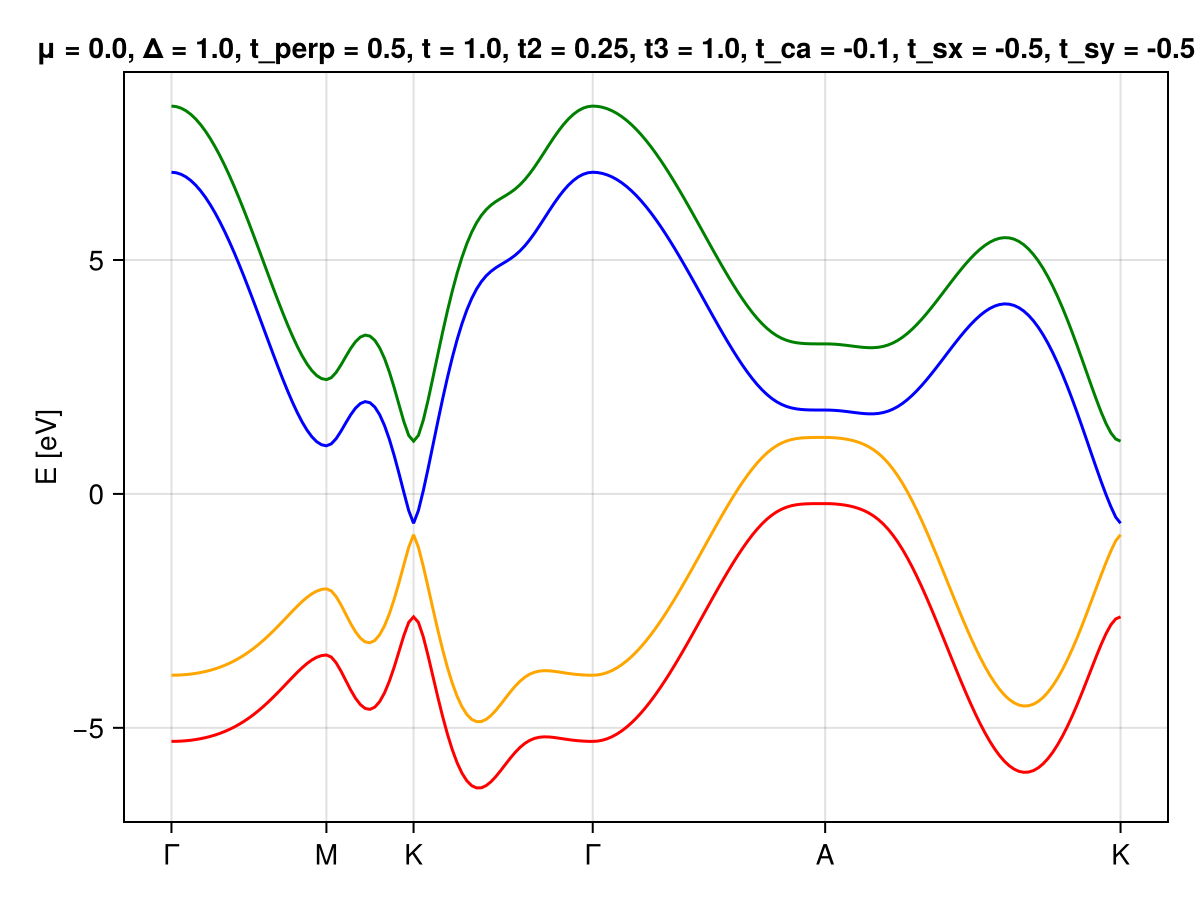

In [73]:
vals, fig = bands_ferroaxial_Gamma_M_K(modelpresets_FA_spinfull(;  μ =0, t =1 ,tp =1, Δ = 1, tpz = 0.5, tc = 0.25, tλ = -0.1, tsx = -0.5, tsy = -0.5))
fig

In [45]:
modelpresets_FA_spinfull(;  μ =0, t =1 ,tp =1, Δ = 1, tpz = 0.5, tc = 0.25, tλ = -0.1, tsx = 100, tsy = 1)

FerroAxialHam_spinfull
  μ: Float64 0.0
  t: Float64 1.0
  tp: Float64 1.0
  Δ: Float64 1.0
  tpz: Float64 0.5
  tc: Float64 0.25
  tλ: Float64 -0.1
  tsx: Float64 100.0
  tsy: Float64 1.0


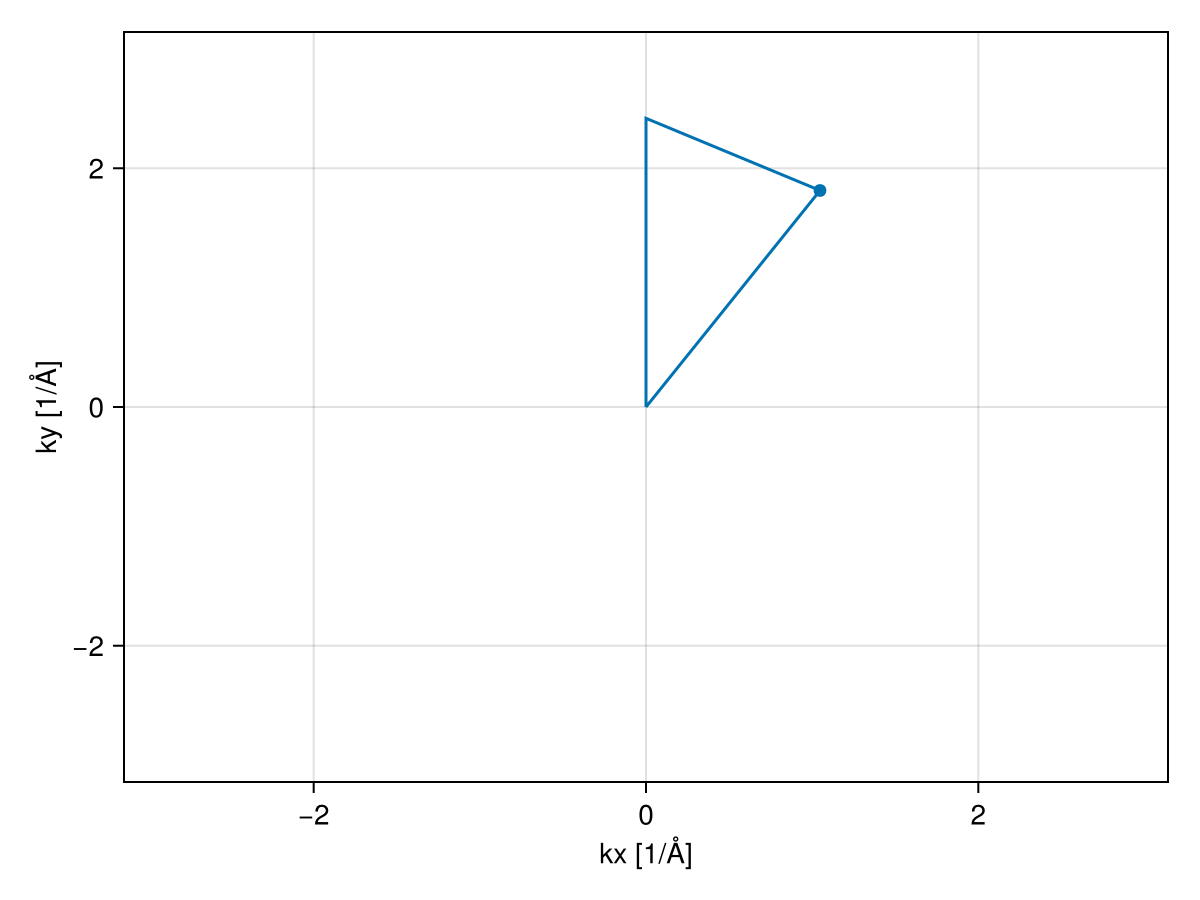

In [33]:
fig_cart = Figure(); ax = Axis(fig_cart[1,1], xlabel = "kx [1/Å]", ylabel = "ky [1/Å]")
# scatter!(ax, K1[1],K1[2])
# scatter!(ax, K2[1],K2[2])
scatter!(ax, M[1],M[2])
# scatter!(ax, Γ[1], Γ[2])
lines!(ax, [ Γ[1], K1[1], K2[1],M[1], Γ[1]], [ Γ[2], K1[2], K2[2], M[2], Γ[2]])
ylims!(ax, -pi, pi)
xlims!(ax, -pi, pi)
fig_cart

## AHE


In [74]:
function ahe_spinfullferroaxial(μ, p; dirj=:x, dirE=:y, T = 10,  evals = 10000, 
    integration_method = :montecarlo, botbounds = [-0.5,-0.5, -0.5], topbounds = [0.5,0.5, 0.5])
    a0 = 1 # Å
    a1, a2, a3, δ1, δ2, δ3 = lattice_vectors(1.0)
    Rs = [a1,a2,a3]
    Gs = dualbasis(Rs)

    # println(Optics_in_the_length_gauge.bz_volume(Gs[1],Gs[2]))
    h(q) = ferroaxial_ham3d_spinfull(q,μ,p.Δ,p.t,p.tp, p.tpz, p.tc, p.tλ)
    dhx(q) =d_ferroaxial_ham3d_spinfull(p.t,p.tp,p.Δ,p.tpz,p.tc, p.tλ,q,:x)
    dhy(q) =d_ferroaxial_ham3d_spinfull(p.t,p.tp,p.Δ,p.tpz,p.tc, p.tλ,q,:y)
    dhz(q) = d_ferroaxial_ham3d_spinfull(p.t,p.tp,p.Δ,p.tpz,p.tc, p.tλ,q,:z)
    dh(q) = [dhx(q), dhy(q), dhz(q)]
    computation = Transport_computation_3d_presets(botbounds,topbounds, evals, integration_method)
    return AH_presets_3d(a0, dirj, dirE, h, dh, T, computation, Gs)
end


ahe_spinfullferroaxial (generic function with 1 method)

In [67]:
comp_pres = ahe_spinfullferroaxial(0.0, modelpresets_FA_spinfull(; μ =-2, t =1 ,tp =0, Δ = 0, tpz = 0, tc = 0., tλ = 0.1))

AH_presets_3d{StaticArraysCore.SVector{3, Vector{Float64}}}
  a0: Float64 1.0
  dirJ: Symbol x
  dirE: Symbol y
  h: h (function of type var"#h#80"{Float64, FerroAxialHam_spinfull})
  dh: dh (function of type var"#dh#84"{var"#dhz#83"{FerroAxialHam_spinfull}, var"#dhy#82"{FerroAxialHam_spinfull}, var"#dhx#81"{FerroAxialHam_spinfull}})
  T: Float64 10.0
  computation: Transport_computation_3d_presets
  gs: StaticArraysCore.SVector{3, Vector{Float64}}


In [68]:
σij_anomalous_hall(comp_pres) 

Montecarlo integration


-5.4240901172005206e-18

In [75]:
p = modelpresets_FA_spinfull(; μ =0, t =1 ,tp =0, Δ = 0, tpz = 1, tc = 0., tλ = 0.1)
mulist = collect(range(-5,15, length = 101));
s = [σij_anomalous_hall(ahe_spinfullferroaxial(μ, p)) for μ in mulist];

Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo integration
Montecarlo 

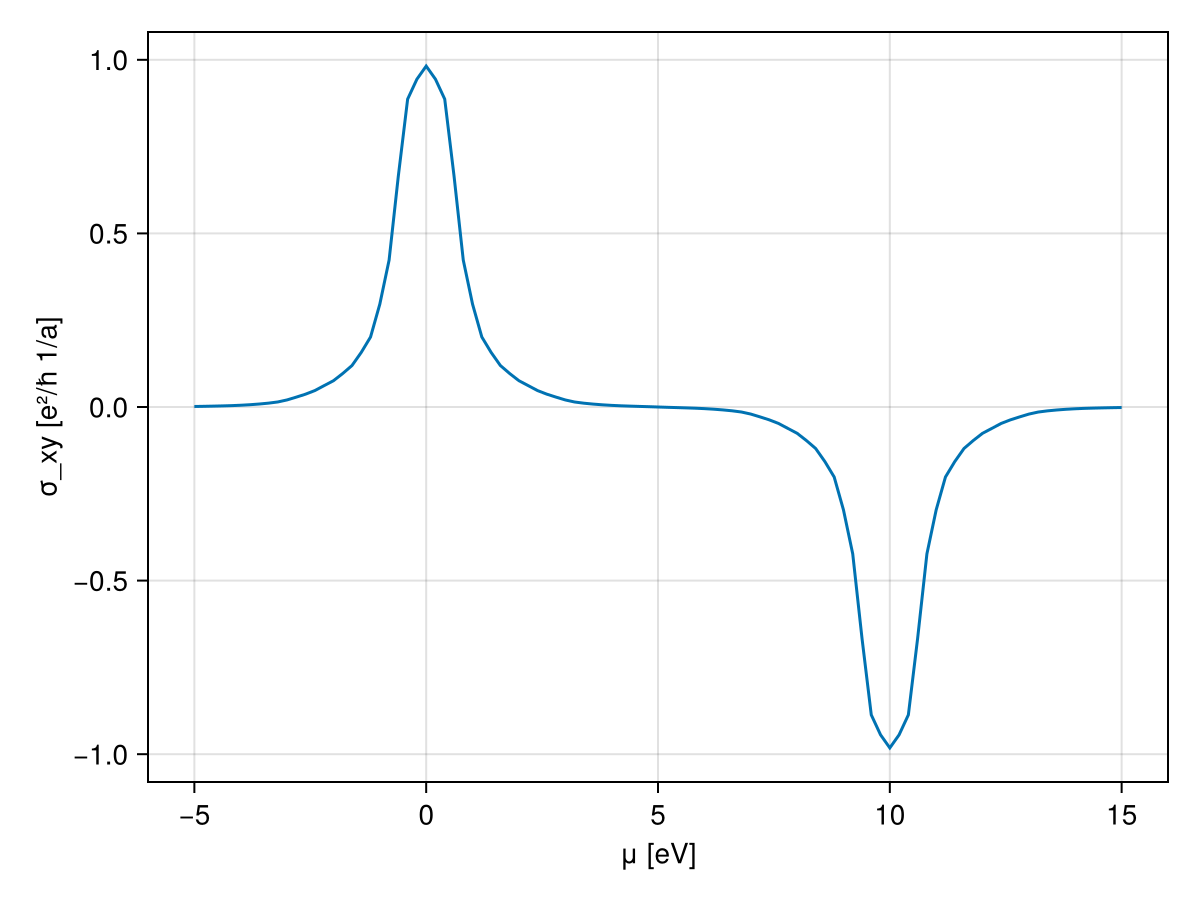

In [76]:
fig = Figure(); ax = Axis(fig[1,1], xlabel = "μ [eV]", ylabel = "σ_xy [e²/ħ 1/a]")
lines!(ax, [m for m in mulist], [i for i in s])
fig

# Fij line

In [55]:

using PhysicalConstants
using PhysicalConstants.CODATA2018
using Unitful
using SparseArrays
using StaticArrays
using Parameters
ħ = PhysicalConstants.CODATA2018.ħ
e = PhysicalConstants.CODATA2018.e

Fij_Gamma_M_K(p, comp_pres, dirF1, dirF2, band; a = 1) = Oij_Gamma_M_K(Optics_in_the_length_gauge.F,p,  comp_pres, dirF1, dirF2, band, a = a )
function Oij_Gamma_M_K(func, p, comp_pres, dirF1, dirF2, band; a = 1)
    N = 400    #kpoints
    mysimpath = [Γ, M , K1, Γ , A , K2]
    Fab(comp_pres, q, band) = func(comp_pres, q, dirF1, dirF2)[band]
    ks = interpolate(mysimpath, N)
    ticks_vals = [Fab(comp_pres, kpoint, 1 ) for kpoint in mysimpath]
    units = 1#(e/ħ |> u"T^-1*Å^-2").val # Fab is computed in Å^3 so the result is Å/T
    
    
    xvals = 1:length(ks)
    
    yvals_1 = [Fab(comp_pres, q, 1 ) for q in ks]
    yvals_2 = [Fab(comp_pres, q, 2) for q in ks]
    yvals_3 = [Fab(comp_pres, q, 3 ) for q in ks]
    yvals_4 = [Fab(comp_pres, q, 4 ) for q in ks]
    
    # position = [findmin(abs.(x .- yvals_1))[2] for x in ticks_vals]
    position =  [1, 66, 103, 178, 275, 398]
    println(position)
    xticks = (vcat(position[1:5],[xvals[end]]), ["Γ", "M", "K1", "Γ", "A", "K2"]) 
    fig = Figure(); ax = Axis(fig[1,1], ylabel = "F$(dirF1)$(dirF2) [Å^3]",  title = "Δ = $(p.Δ), t_perp = $(p.tpz), t = $(p.t), t2 = $(p.tc), t3 = $(p.tp), tλ = $(p.tλ) [eV]",  xticks=xticks)
    # scatter!(ax, xvals, yvals_1, color = :red)#, label = "Lower band")
    colorlist = [:red, :orange, :blue, :green]
    lines!(ax, xvals, yvals_1, color = :red, label = "1")
    lines!(ax, xvals, yvals_2, color = :orange,  label = "2")
    lines!(ax, xvals, yvals_3, color = :blue, linestyle = :dash,  label = "3")
    lines!(ax, xvals, yvals_4, color = :green, linestyle = :dash, label = "4")
    
    xlims!(ax, 1, N)
    # ylims!(ax, -0.025,0.025)
    # ax.yticks = (-0.4:0.05:0.4)#, string.(-10:9))
    axislegend(ax, position = :lt)
    if maximum(abs.(yvals_1))< 1e-5
        ylims!(ax, -1e-7,1e-7)
    end
    return yvals_1, yvals_2, fig
end

Oij_Gamma_M_K (generic function with 1 method)

In [62]:
band = 1
a = 1
R1, R2, R3, δ1, δ2, δ3 = lattice_vectors(1.0)
Rs = [R1,R2,R3]

kws = (PS_orbital_switch = false, QM_switch = true)
p = modelpresets_FA_spinfull(;  μ =0, t =1 ,tp =1, Δ = 1, tpz = 0.5, tc = 0.25, tλ = -0.1, tsx = -1, tsy = -0.5)
comp_pres = sigma_abc_ferroaxial_wrapper_3d_spinfull(p; kws...);


[1, 66, 103, 178, 275, 398]


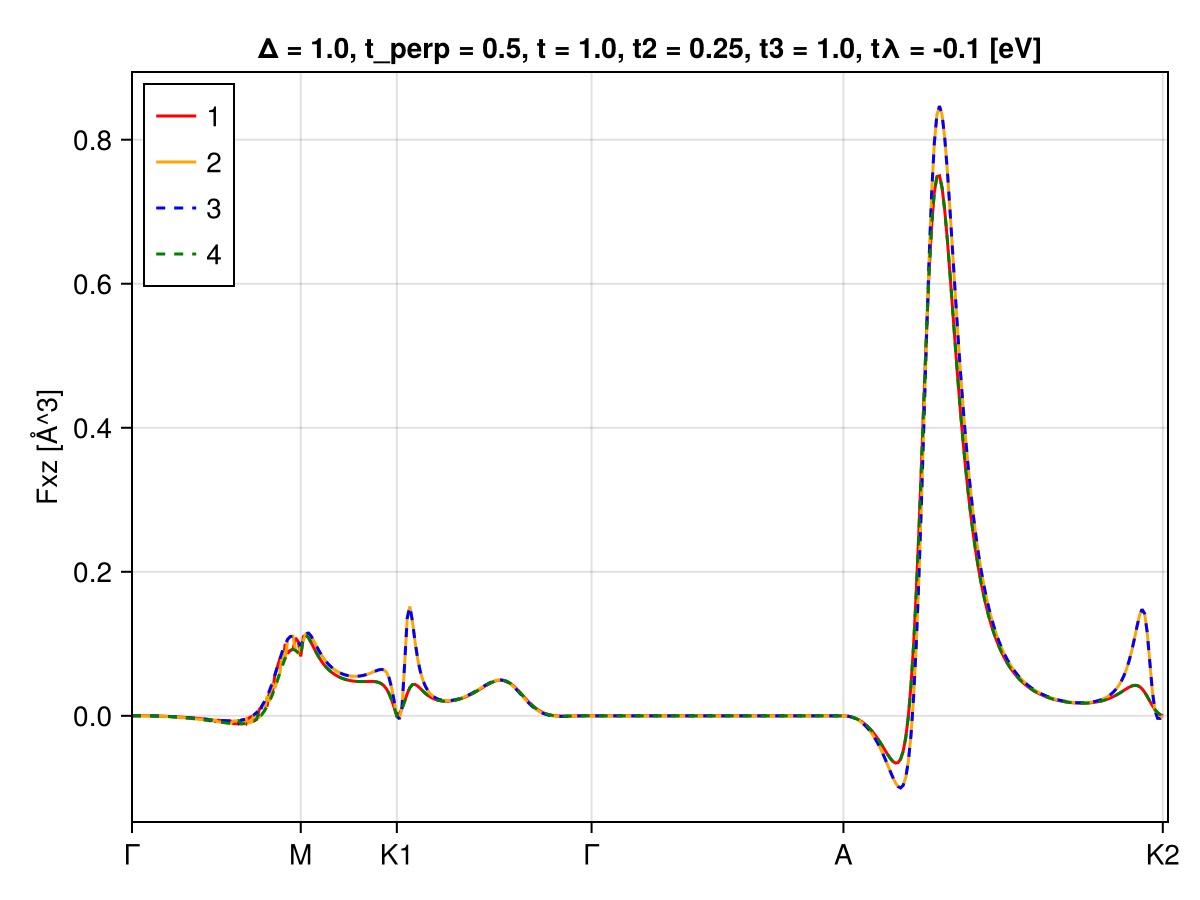

In [66]:

dir1 = :x
dir2 = :z
# Method reusing the OMM
yvals0_1, yvals0_2, fig = Oij_Gamma_M_K(Optics_in_the_length_gauge.F, p, comp_pres, dir1, dir2, 1)
fig
